# HumanForYou - Exploration des données

HumanForYou est une entreprise pharmaceutique d'environ 4400 employés qui perd chaque année autour de 15% de ses effectifs. C'est beaucoup. L'objectif de ce projet, c'est de comprendre pourquoi des employés partent et de construire un modèle capable de prédire qui risque de quitter l'entreprise.

On commence par explorer les données avant de toucher quoi que ce soit. C'est indispensable pour comprendre ce qu'on a entre les mains et éviter de faire n'importe quoi dans les étapes suivantes.

## Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

RAW = '../data/raw/'

## 1. Chargement

On a 5 fichiers à disposition. L'idée c'est de les fusionner ensuite sur l'identifiant employé.

In [ ]:
general  = pd.read_csv(RAW + 'general_data.csv')
survey   = pd.read_csv(RAW + 'employee_survey_data.csv')
manager  = pd.read_csv(RAW + 'manager_survey_data.csv')
in_time  = pd.read_csv(RAW + 'in_time.csv', index_col=0)
out_time = pd.read_csv(RAW + 'out_time.csv', index_col=0)

print(f"general_data    : {general.shape}")
print(f"employee_survey : {survey.shape}")
print(f"manager_survey  : {manager.shape}")
print(f"in_time         : {in_time.shape}")
print(f"out_time        : {out_time.shape}")

## 2. Aperçu rapide

On jette un oeil à la structure et aux types de colonnes.

In [ ]:
general.head()

In [ ]:
general.info()

In [ ]:
general.describe(include='all').T

## 3. La variable cible : Attrition

C'est ce qu'on cherche à prédire. "Yes" = l'employé a quitté l'entreprise, "No" = il est resté. On voit directement qu'il y a un déséquilibre : environ 84% de restants pour 16% de partants. Ca va influencer nos choix de modélisation.

In [ ]:
attr_counts = general['Attrition'].value_counts()
attr_pct    = general['Attrition'].value_counts(normalize=True) * 100

print(attr_counts)
print()
print(attr_pct.round(1).astype(str) + ' %')

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(attr_counts.index, attr_counts.values, color=['#4C72B0', '#DD8452'])
for i, (label, val) in enumerate(zip(attr_counts.index, attr_counts.values)):
    axes[0].text(i, val + 30, str(val), ha='center', fontsize=12)
axes[0].set_title('Effectif par classe')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Nombre d\'employés')

axes[1].pie(attr_counts.values, labels=attr_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Répartition')

plt.suptitle('Distribution de la variable cible (Attrition)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/attrition_distribution.png', bbox_inches='tight')
plt.show()

print(f"\n84% restent, 16% partent â†' déséquilibre à gérer dans la modélisation")

## 4. Colonnes inutiles

Avant de modéliser, on vérifie s'il y a des colonnes qui n'apportent aucune information. Une colonne avec la même valeur pour tout le monde ne peut pas aider un modèle à faire des distinctions.

In [ ]:
nunique = general.nunique()
constant_cols = nunique[nunique == 1].index.tolist()
print("Colonnes constantes :", constant_cols)
for col in constant_cols:
    print(f"  {col} â†' {general[col].unique()}")

`EmployeeCount`, `Over18` et `StandardHours` ont la même valeur pour les 4410 employés. On les supprime, elles ne servent à rien.

## 5. Valeurs manquantes

On regarde combien de données manquent et dans quelles colonnes.

In [ ]:
def missing_summary(df, name):
    na = df.isna().sum()
    na = na[na > 0]
    if na.empty:
        print(f"{name} : pas de NA")
    else:
        pct = (na / len(df) * 100).round(2)
        print(f"\n{name} :")
        for col in na.index:
            print(f"  {col:35s} {na[col]:4d} ({pct[col]:.2f}%)")

missing_summary(general, 'general_data')
missing_summary(survey,  'employee_survey')
missing_summary(manager, 'manager_survey')

Peu de NA partout (moins de 1%). On peut se permettre d'imputer plutôt que de supprimer des lignes - on perdrait de l'information pour rien. La médiane sera préférée à la moyenne parce qu'elle est moins sensible aux valeurs extrêmes.

## 6. Distributions des variables numériques

On visualise les distributions pour repérer des formes particulières, des valeurs aberrantes, ou des variables qui pourraient être discriminantes.

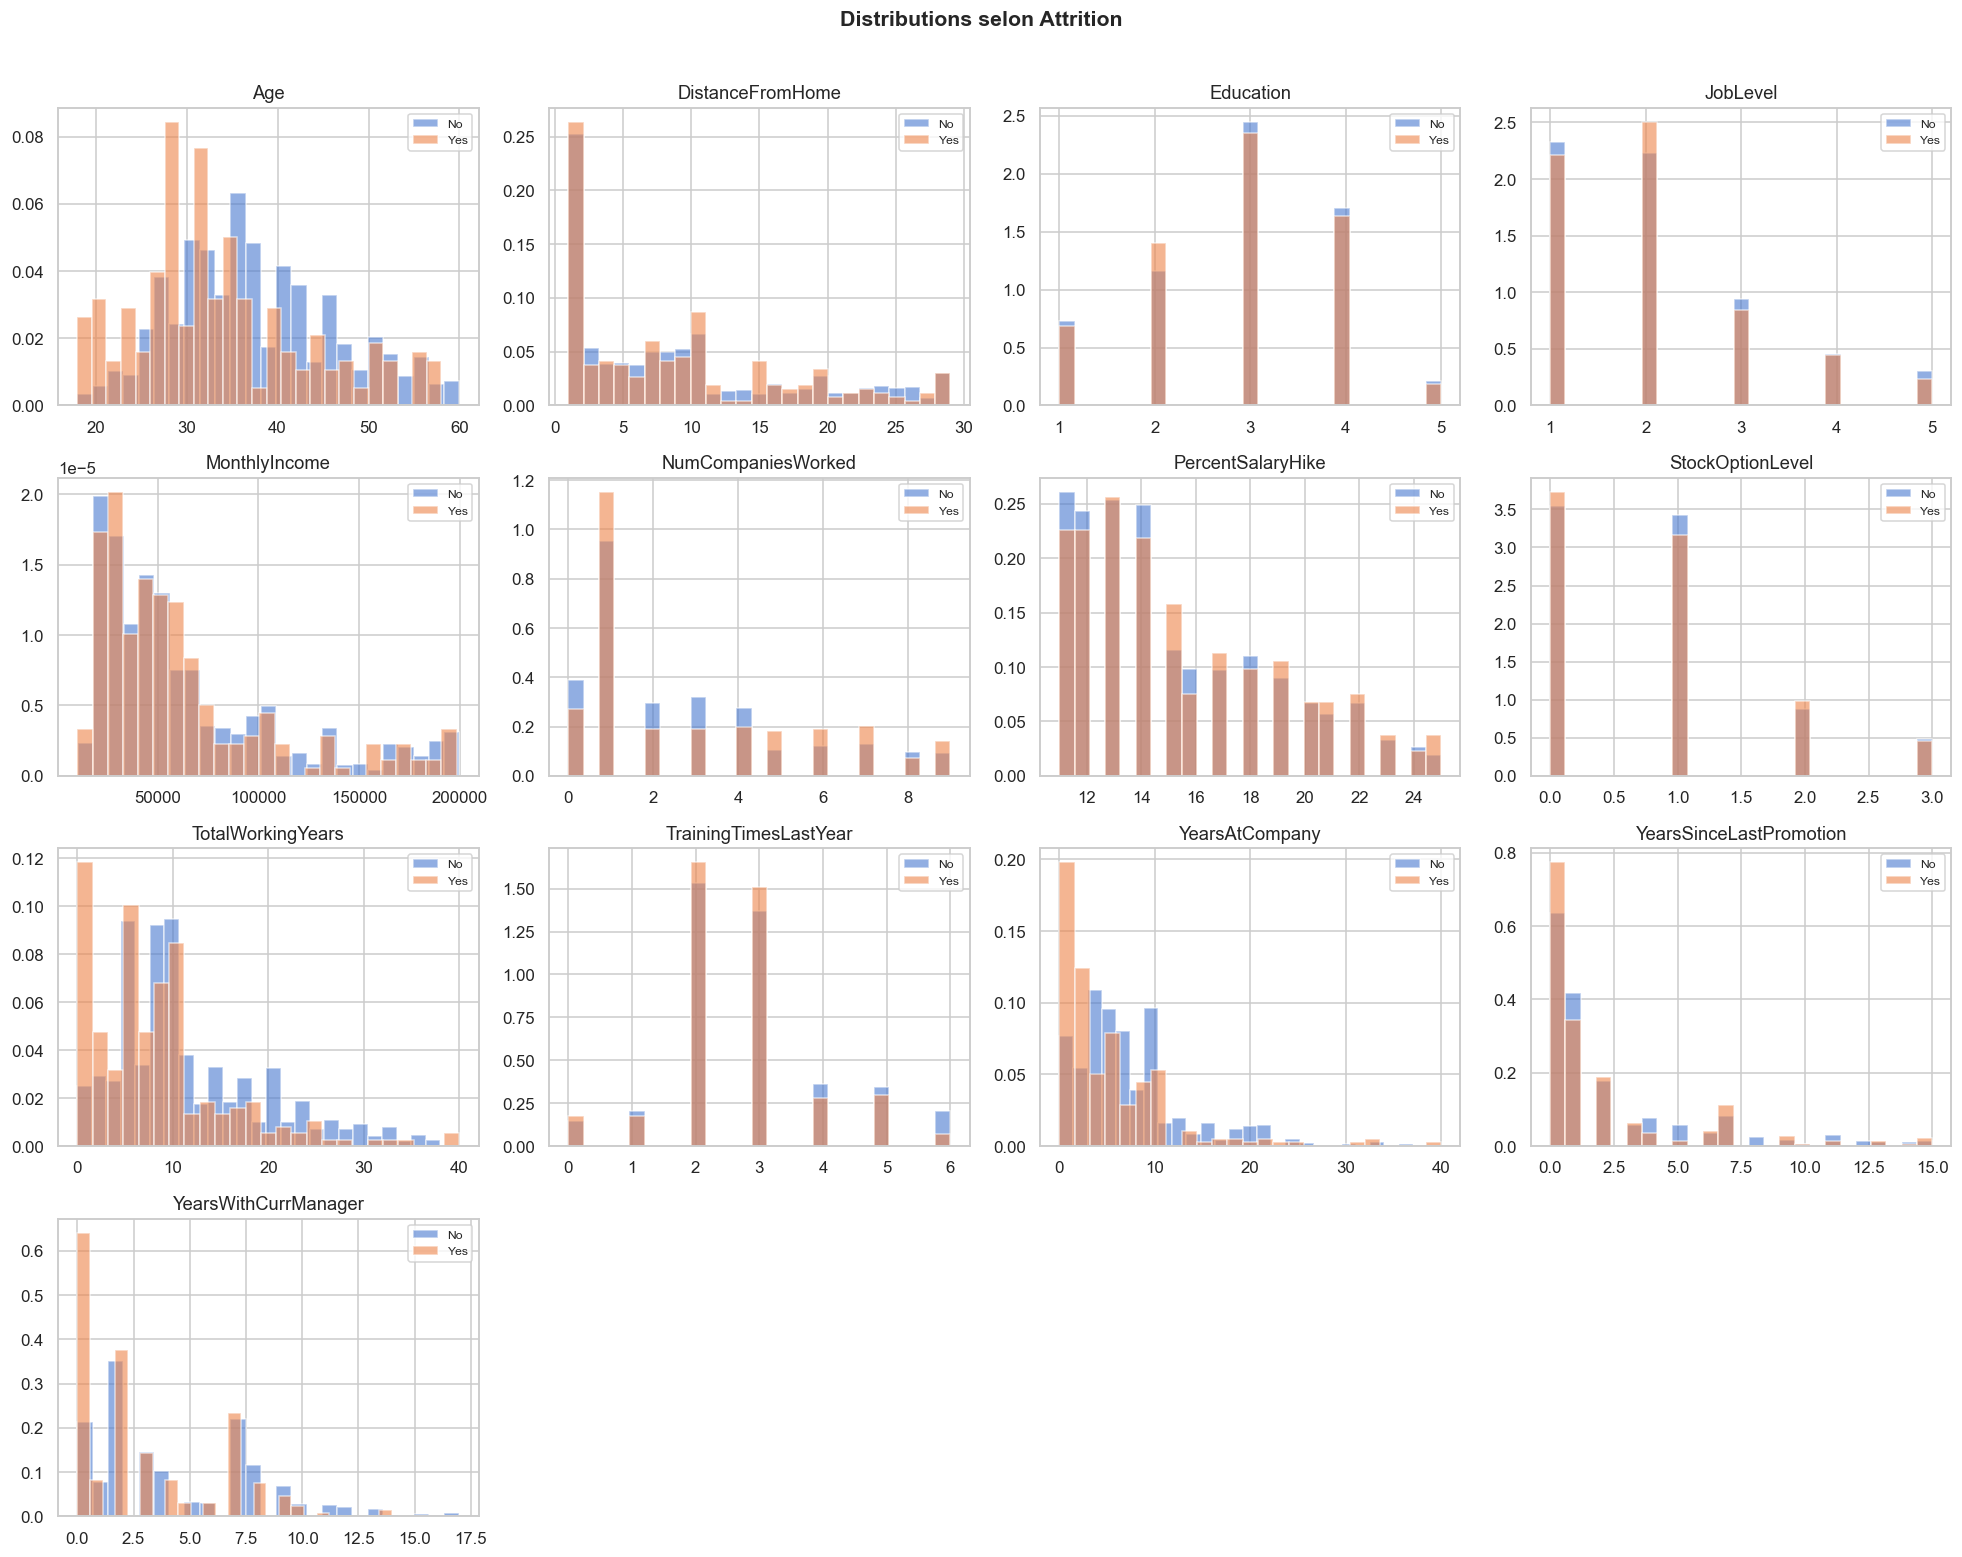

In [41]:
num_cols = general.select_dtypes(include='number').columns.drop(['EmployeeID', 'EmployeeCount', 'StandardHours'])

n_cols = 4
n_rows = -(-len(num_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, grp in general.groupby('Attrition'):
        axes[i].hist(grp[col].dropna(), bins=25, alpha=0.6, label=label, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions selon Attrition', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/numeric_distributions.png', bbox_inches='tight')
plt.show()

## 7. Variables catégorielles vs Attrition

Pour chaque variable catégorielle, on calcule le taux de départ par modalité. Ca permet de voir si certaines catégories sont plus à risque que d'autres.

In [ ]:
cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    tbl = general.groupby([col, 'Attrition']).size().unstack(fill_value=0)
    tbl_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100
    tbl_pct.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'], edgecolor='white')
    axes[i].set_title(f'Attrition par {col}')
    axes[i].set_xlabel('')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Attrition')

plt.suptitle('Taux d\'attrition par variable catégorielle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/categorical_attrition.png', bbox_inches='tight')
plt.show()

### V de Cramér : mesure d'association chiffrée

Les bar charts montrent visuellement les différences, mais pour avoir un score comparable entre variables on calcule le **V de Cramér**. C'est la mesure standard pour quantifier l'association entre deux variables catégorielles, dérivée du chi². Score entre 0 (aucun lien) et 1 (lien parfait). Convention : moins de 0.1 = négligeable, 0.1 à 0.3 = faible, plus de 0.3 = modéré à fort.

Association (V de Cramer) entre variables categorielle et Attrition :
  (0 = aucun lien, 1 = lien parfait)
  BusinessTravel            V = 0.1283
  Department                V = 0.0812
  EducationField            V = 0.1023
  Gender                    V = 0.0175
  JobRole                   V = 0.0755
  MaritalStatus             V = 0.1772


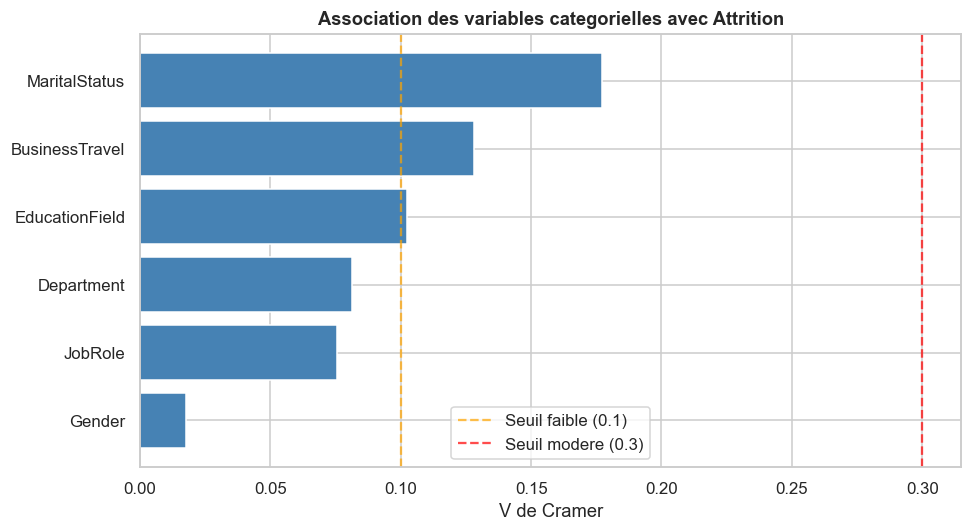

In [40]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cat_cols_cramer = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

scores_cramer = {}
print("Association (V de Cramer) entre variables categorielle et Attrition :")
print(f"  (0 = aucun lien, 1 = lien parfait)")
for col in cat_cols_cramer:
    v = cramers_v(general[col], general['Attrition'])
    scores_cramer[col] = round(v, 4)
    print(f"  {col:<25} V = {v:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
cols_sorted = sorted(scores_cramer, key=scores_cramer.get, reverse=True)
vals = [scores_cramer[c] for c in cols_sorted]
ax.barh(cols_sorted[::-1], vals[::-1], color='steelblue')
ax.set_xlabel("V de Cramer")
ax.set_title("Association des variables categorielles avec Attrition", fontweight='bold')
ax.axvline(0.1, color='orange', linestyle='--', alpha=0.7, label='Seuil faible (0.1)')
ax.axvline(0.3, color='red',    linestyle='--', alpha=0.7, label='Seuil modere (0.3)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/cramer_v_categoriel.png', bbox_inches='tight')
plt.show()

Les scores de V de Cramér sont faibles pour les variables catégorielles, ce qui suggère que les liens avec l'attrition sont limités. Cela confirme que les variables clés sont probablement les numériques et que les catégorielles ne seront pas très utiles pour la modélisation.

## 8. Satisfaction (enquête employés)

Ces variables viennent d'une enquête de satisfaction interne. Elles sont notées de 1 (faible) à 4 (élevé). On regarde si les scores diffèrent entre partants et restants.

In [ ]:
survey_merged = survey.merge(general[['EmployeeID', 'Attrition']], on='EmployeeID')

sat_cols = ['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(sat_cols):
    tbl = survey_merged.groupby([col, 'Attrition']).size().unstack(fill_value=0)
    tbl_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100
    tbl_pct.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'], edgecolor='white')
    axes[i].set_title(col)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Attrition')
    axes[i].set_xlabel('Score (1=faible â†' 4=élevé)')

plt.suptitle('Taux d\'attrition selon la satisfaction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/satisfaction_attrition.png', bbox_inches='tight')
plt.show()

### Biais des non-répondants à l'enquête satisfaction

86 employés n'ont pas répondu à au moins une question de l'enquête. Avant d'imputer par la médiane, on vérifie si ces non-répondants sont surreprésentés parmi les départs. Si c'est le cas, l'imputation masquerait un signal important.

In [39]:
survey_na = survey.copy()
survey_na = survey_na.merge(general[['EmployeeID', 'Attrition']], on='EmployeeID')
has_na    = survey_na[['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance']].isna().any(axis=1)

taux_repondants    = (survey_na[~has_na]['Attrition'] == 'Yes').mean() * 100
taux_nonrepondants = (survey_na[has_na]['Attrition']  == 'Yes').mean() * 100

print(f"Repondants complets ({(~has_na).sum()} employes) : {taux_repondants:.1f}% de departs")
print(f"Non-repondants      ({has_na.sum()} employes) : {taux_nonrepondants:.1f}% de departs")

Repondants complets (4327 employes) : 16.2% de departs
Non-repondants      (83 employes) : 12.0% de departs


Resultat : les non-repondants ont un taux de depart INFERIEUR (12% vs 16%).
Ce resultat est contre-intuitif on pourrait s'attendre à ce que les
insatisfaits ne repondent pas. Mais ici rien ne prouve que le silence
signale un mal-etre. L'imputation par mediane ne semble pas introduire
de biais majeur, et on le documente clairement.

## 9. Evaluation manager

Deux variables issues de l'évaluation faite par les managers. `PerformanceRating` ne prend que les valeurs 3 et 4 dans nos données - tout le monde est bien noté, ce qui la rend peu utile. `JobInvolvement` est plus intéressante.

In [ ]:
manager_merged = manager.merge(general[['EmployeeID', 'Attrition']], on='EmployeeID')

print(f"JobInvolvement    : {sorted(manager['JobInvolvement'].unique())}")
print(f"PerformanceRating : {sorted(manager['PerformanceRating'].unique())}")
print(f"NA : {manager.isna().sum().to_dict()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['JobInvolvement', 'PerformanceRating']):
    tbl = manager_merged.groupby([col, 'Attrition']).size().unstack(fill_value=0)
    tbl_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100
    tbl_pct.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'], edgecolor='white')
    axes[i].set_title(f'Attrition par {col}')
    axes[i].set_xlabel(f'{col} (1=faible â†' 4=élevé)')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Attrition')

plt.suptitle("Attrition selon l'évaluation manager", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/manager_survey_attrition.png', bbox_inches='tight')
plt.show()

print("\nTaux de départ par JobInvolvement :")
print(manager_merged.groupby('JobInvolvement')['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100).round(1).to_string())

`PerformanceRating` ne prend que les valeurs 3 et 4 dans nos données. Tout le monde est évalué "Excellent" ou "Au-delà des attentes". Cette variable est quasi-constante : elle sera conservée mais apportera peu au modèle. Les évaluations managers semblent peu différenciantes, contrairement à l'auto-déclaration des employés (`JobInvolvement` est plus discriminante).

## 10. Corrélations

On regarde les corrélations entre variables numériques pour repérer des liens forts et éviter la redondance.

In [ ]:
gen_corr = general.copy()
gen_corr['Attrition_bin'] = (gen_corr['Attrition'] == 'Yes').astype(int)

num_corr_cols = list(num_cols) + ['Attrition_bin']
corr_matrix = gen_corr[num_corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Matrice de corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlation_matrix.png', bbox_inches='tight')
plt.show()

In [ ]:
corr_with_target = corr_matrix['Attrition_bin'].drop('Attrition_bin').sort_values(key=abs, ascending=False)
print("Top corrélations avec Attrition :")
print(corr_with_target.round(3).to_string())

Les corrélations entre variables à retenir : `TotalWorkingYears` et `Age` sont fortement corrélés (~0.68), tout comme `YearsAtCompany` et `YearsWithCurrManager` (~0.77). Ce sont des paires logiques - plus on vieillit, plus on a d'expérience ; plus on est ancré dans l'entreprise, plus on a eu de temps sous le même manager.

Cette redondance ne justifie pas une suppression manuelle à ce stade. On la traitera dans le notebook dédié à la sélection de variables : si deux features sont vraiment redondantes, les méthodes de filtrage et l'importance du modèle le confirmeront avec des scores chiffrés.

## 11. Données de badgeage

On a les heures d'entrée et de sortie pour 261 jours ouvrés de l'année 2015. Impossible de donner 261 colonnes de dates brutes à un modèle - on va en extraire des indicateurs synthétiques.

In [ ]:
in_dt  = in_time.apply(pd.to_datetime, errors='coerce')
out_dt = out_time.apply(pd.to_datetime, errors='coerce')

work_hours = (out_dt - in_dt).apply(lambda s: s.dt.total_seconds() / 3600)

badge_features = pd.DataFrame()
badge_features['EmployeeID']        = general['EmployeeID'].values
badge_features['avg_hours_per_day'] = work_hours.mean(axis=1).values
badge_features['std_hours_per_day'] = work_hours.std(axis=1).values
badge_features['days_absent']       = work_hours.isna().sum(axis=1).values
badge_features['days_over_8h']      = (work_hours > 8).sum(axis=1).values
badge_features['avg_arrival_hour']  = in_dt.apply(
    lambda col: col.dt.hour + col.dt.minute / 60).mean(axis=1).values

badge_merged = badge_features.merge(general[['EmployeeID', 'Attrition']], on='EmployeeID')

# Visualisation des 5 indicateurs
badge_plot_cols = [
    ('avg_hours_per_day',  'Heures moy. / jour'),
    ('std_hours_per_day',  'Variabilite heures (ecart-type)'),
    ('days_absent',        'Jours absents'),
    ('days_over_8h',       'Jours > 8h'),
    ('avg_arrival_hour',   "Heure d'arrivee moy."),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for i, (col, label) in enumerate(badge_plot_cols):
    for val, grp in badge_merged.groupby('Attrition'):
        axes[i].hist(grp[col].dropna(), bins=30, alpha=0.6, label=val, density=True)
    axes[i].set_title(label)
    axes[i].legend(title='Attrition')

axes[5].set_visible(False)
plt.suptitle('Indicateurs badgeuse selon Attrition (5 features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/badge_features_attrition.png', bbox_inches='tight')
plt.show()

# Tableau comparatif moyennes partants vs restants
restants_b = badge_merged[badge_merged['Attrition'] == 'No']
partants_b  = badge_merged[badge_merged['Attrition'] == 'Yes']

print("Moyennes par groupe (indicateurs badgeage) :")
print(f"  {'Feature':<32} {'Restants':>10} {'Partants':>10} {'Difference':>12}")
print("  " + "-"*66)
for col, label in badge_plot_cols:
    m_r = restants_b[col].mean()
    m_p = partants_b[col].mean()
    delta = m_p - m_r
    pct = (delta / m_r * 100) if m_r != 0 else 0
    print(f"  {label:<32} {m_r:>10.2f} {m_p:>10.2f} {delta:>+10.2f} ({pct:+.1f}%)")


## Synthèse : signaux identifiés par famille de variables

On regroupe ici les variables qui montrent le signal le plus clair vis-à-vis de l'attrition, selon la méthode adaptée à leur type. Ce classement alimente directement les choix de preprocessing et de sélection de variables.

In [35]:
# 1. Variables numériques : corrélation de Pearson avec Attrition
gen_s = general.copy()
gen_s['Attrition_bin'] = (gen_s['Attrition'] == 'Yes').astype(int)
num_c = gen_s.select_dtypes(include='number').drop(
    columns=['EmployeeID', 'EmployeeCount', 'StandardHours', 'Attrition_bin'])

pearson = gen_s[list(num_c.columns) + ['Attrition_bin']].corr()['Attrition_bin'].drop('Attrition_bin')
pearson = pearson.abs().sort_values(ascending=False)

print("=== Variables numeriques (|Pearson| avec Attrition) ===")
print(f"  {'Variable':<28} {'|r|':>6}  Signal")
print("  " + "-"*50)
for col, r in pearson.items():
    niveau = "fort" if r > 0.15 else ("modere" if r > 0.08 else "faible")
    print(f"  {col:<28} {r:>6.3f}  {niveau}")

# 2. Variables catégorielles : V de Cramér avec Attritionâ
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

cat_s = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']
cramer_scores = {col: cramers_v(gen_s[col], gen_s['Attrition']) for col in cat_s}
cramer_sorted = sorted(cramer_scores.items(), key=lambda x: x[1], reverse=True)

print()
print("=== Variables categorielles (V de Cramer avec Attrition) ===")
print(f"  {'Variable':<28} {'V':>6}  Signal")
print("  " + "-"*50)
for col, v in cramer_sorted:
    niveau = "modere" if v > 0.15 else ("faible" if v > 0.08 else "tres faible")
    print(f"  {col:<28} {v:>6.3f}  {niveau}")

# 3. Indicateurs badgeage : ecart moyen partants vs restants
in_dt_s  = in_time.apply(pd.to_datetime, errors='coerce')
out_dt_s = out_time.apply(pd.to_datetime, errors='coerce')
wh_s     = (out_dt_s - in_dt_s).apply(lambda s: s.dt.total_seconds() / 3600)

bf = pd.DataFrame({
    'EmployeeID'       : general['EmployeeID'].values,
    'avg_hours_per_day': wh_s.mean(axis=1).values,
    'std_hours_per_day': wh_s.std(axis=1).values,
    'days_absent'      : wh_s.isna().sum(axis=1).values,
    'days_over_8h'     : (wh_s > 8).sum(axis=1).values,
    'avg_arrival_hour' : in_dt_s.apply(lambda c: c.dt.hour + c.dt.minute/60).mean(axis=1).values,
})
bf = bf.merge(general[['EmployeeID', 'Attrition']], on='EmployeeID')
rest_s = bf[bf['Attrition'] == 'No']
part_s = bf[bf['Attrition'] == 'Yes']

badge_labels = {
    'avg_hours_per_day': 'Heures moy/jour',
    'std_hours_per_day': 'Variabilite heures',
    'days_absent':       'Jours absents',
    'days_over_8h':      'Jours > 8h',
    'avg_arrival_hour':  "Heure d'arrivee moy",
}

print()
print("=== Indicateurs badgeage (ecart partants vs restants) ===")
print(f"  {'Feature':<22} {'Restants':>10} {'Partants':>10} {'Delta':>8}  Signal")
print("  " + "-"*64)
for col, label in badge_labels.items():
    m_r = rest_s[col].mean()
    m_p = part_s[col].mean()
    d   = m_p - m_r
    pct = abs(d / m_r * 100) if m_r != 0 else 0
    niveau = "modere" if pct > 5 else "faible"
    print(f"  {label:<22} {m_r:>10.2f} {m_p:>10.2f} {d:>+8.2f}  {niveau} ({pct:.1f}%)")

# 4. Variables ordinalées satisfaction/manager
surv_s = survey.merge(general[['EmployeeID', 'Attrition']], on='EmployeeID')
surv_s[['EnvironmentSatisfaction','JobSatisfaction','WorkLifeBalance']] = \
    surv_s[['EnvironmentSatisfaction','JobSatisfaction','WorkLifeBalance']].apply(
        pd.to_numeric, errors='coerce')
surv_s['Attrition_bin'] = (surv_s['Attrition'] == 'Yes').astype(int)

mgr_s = manager.merge(general[['EmployeeID', 'Attrition']], on='EmployeeID')
mgr_s['Attrition_bin'] = (mgr_s['Attrition'] == 'Yes').astype(int)

ord_vars = {
    **{c: surv_s for c in ['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance']},
    **{c: mgr_s  for c in ['JobInvolvement', 'PerformanceRating']},
}

print()
print("=== Variables ordinales satisfaction/manager (|Pearson| avec Attrition) ===")
print(f"  {'Variable':<28} {'|r|':>6}  Signal")
print("  " + "-"*50)
for col, df_tmp in ord_vars.items():
    r = abs(df_tmp[[col, 'Attrition_bin']].dropna().corr().iloc[0, 1])
    niveau = "modere" if r > 0.12 else ("faible" if r > 0.05 else "tres faible")
    print(f"  {col:<28} {r:>6.3f}  {niveau}")


=== Variables numeriques (|Pearson| avec Attrition) ===
  Variable                        |r|  Signal
  --------------------------------------------------
  TotalWorkingYears             0.170  fort
  Age                           0.159  fort
  YearsWithCurrManager          0.156  fort
  YearsAtCompany                0.134  modere
  TrainingTimesLastYear         0.049  faible
  NumCompaniesWorked            0.042  faible
  YearsSinceLastPromotion       0.033  faible
  PercentSalaryHike             0.033  faible
  MonthlyIncome                 0.031  faible
  Education                     0.015  faible
  JobLevel                      0.010  faible
  DistanceFromHome              0.010  faible
  StockOptionLevel              0.007  faible

=== Variables categorielles (V de Cramer avec Attrition) ===
  Variable                          V  Signal
  --------------------------------------------------
  MaritalStatus                 0.177  modere
  BusinessTravel                0.128  faible


**Ce qu'on retient - classement par force du signal :**

**Signal fort :**
- `days_over_8h` : les partants font +96% de journées longues (129 vs 66 jours). C'est le signal le plus fort du dataset.
- `avg_hours_per_day` : +9.7% d'heures par jour. Les partants restent structurellement plus longtemps au bureau. Ces deux variables suggèrent que la surcharge de travail est un facteur majeur.

**Signal modéré :**
- `TotalWorkingYears`, `Age`, `YearsAtCompany` : corrélations Pearson de 0.13 à 0.17. Attention : corrélations en partie structurelles (les employés âgés et expérimentés sont naturellement plus stables). Réels mais moins actionnables que le badgeage.
- `JobSatisfaction`, `EnvironmentSatisfaction` : les insatisfaits partent plus, écarts modérés.
- `JobInvolvement` : les employés peu impliqués partent davantage.
- `MaritalStatus` (V de Cramér ~ 0.15-0.20) : les célibataires partent plus.
- `BusinessTravel` : les employés en déplacement fréquent ont un taux d'attrition plus élevé.

**Signal faible ou non-exploitable :**
- `PerformanceRating` : quasi-constante (valeurs 3 et 4 seulement).
- `Gender`, `EducationField`, `Department` : V de Cramér < 0.1, pas de lien significatif avec l'attrition. Les scores de V de Cramér sont faibles pour toutes les variables catégorielles, ce qui suggère que les liens avec l'attrition sont limités. Cela confirme que les variables clés sont probablement numériques et que les catégorielles seront moins utiles pour la modélisation.
- `days_absent`, `std_hours_per_day`, `avg_arrival_hour` : écarts négligeables entre partants et restants.

**Note sur les non-répondants enquête satisfaction :**
Taux de départ plus bas chez les non-répondants (12% vs 16%). Pas de biais identifié, imputation médiane justifiée.

**Ce que la modélisation devra confirmer :**
La corrélation Pearson ne capture pas les effets non-linéaires ni les interactions. Le Random Forest (notebooks 03-04) donnera un classement d'importance plus fiable, notamment pour `MonthlyIncome` que Pearson sous-estime.

On passe au preprocessing (notebook 02).